# Llama with LoRA

This notebook uses an off the shelf Llama model slightly trained with LoRa to classify a news article into one of five bias labels. We freeze Llama and add a classification head to create a baseline Llama implementation before going on to LoRA in the next notebook. 

In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader      

from transformers import AutoTokenizer

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler


import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.llama_lora import LlamaClassifier

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ]
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['combined']


Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 8
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(LlamaClassifier, model_id=model_id, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [6]:
print('Training base dataset net')
net.fit(train, torch.tensor(train.labels))

Training base dataset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr       dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  --------
      1       0.1421      0.1047        1.6452       0.1343      0.1042        1.6813  0.0000  274.2594
      2       0.1556      0.1299        1.6331       0.1547      0.1389        1.6557  0.0000  275.4606
      3       0.2108      0.2182        1.6007       0.2467      0.2792        1.6169  0.0000  275.2700
      4       0.3281      0.3583        1.5663       0.3547      0.3788        1.5843  0.0000  275.3693
      5       0.4114      0.4278        1.5340       0.4190      0.4292        1.5482  0.0000  275.3318
      6       0.4768      0.4871        1.4874       0.4745      0.4829        1.4875  0.0000  275.4291
      7       0.5115      0.5244        1.4064       0.4891      0.5057        1.3979  0.0000  275.3556
      8       0.5309      0.5487      

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LlamaClassifier(
    (llama): PeftModelForSequenceClassification(
      (base_model): LoraModel(
        (model): LlamaModel(
          (embed_tokens): Embedding(32000, 2048)
          (layers): ModuleList(
            (0-21): 22 x LlamaDecoderLayer(
              (self_attn): LlamaAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=256, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=256, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (o_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
              )
              (mlp): LlamaMLP(
                (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
                (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
                (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
                (act_fn): SiLU()
              )
              (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
              (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
            )
          )
          (norm): LlamaRMSNorm((2048,), eps=1e-05)
          (rotary_emb): LlamaRotaryEmbedding()
        )
      )
    )
    (classifier): Linear(in_features=2048, out_features=5, bias=True)
  ),
)

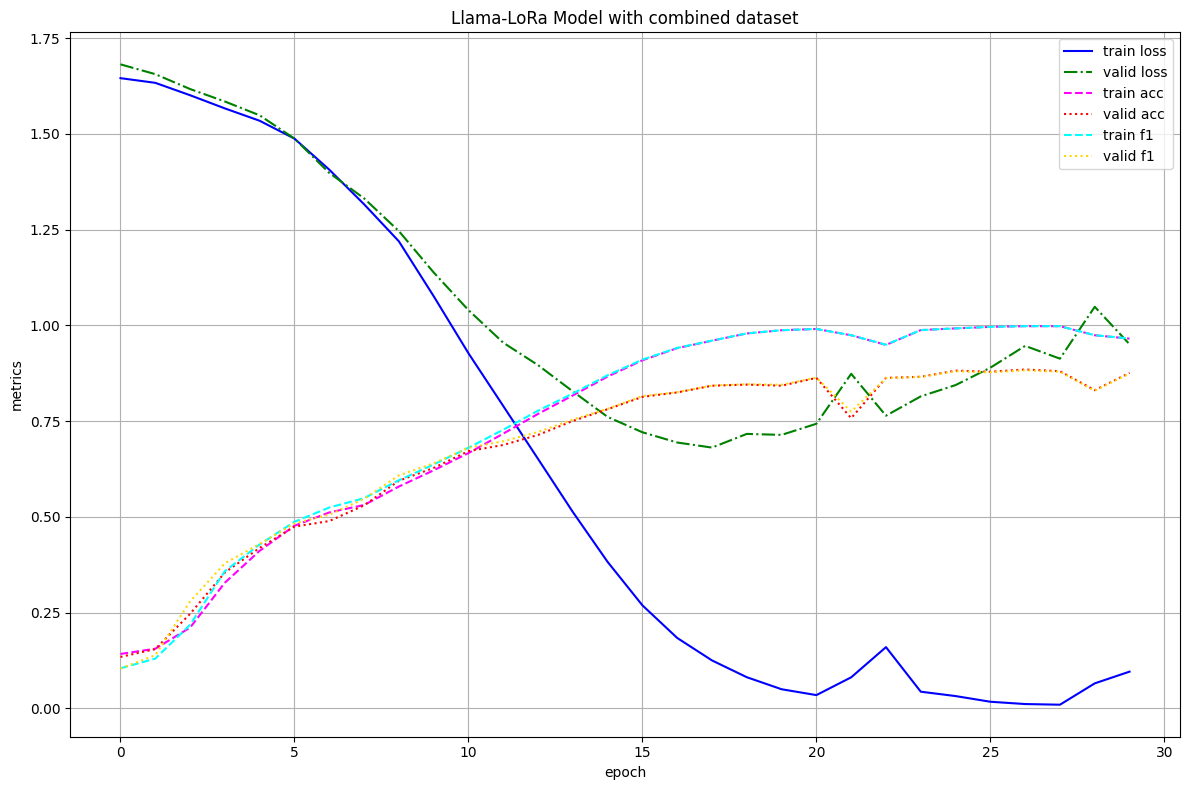

In [7]:
from utils import plot_result_curves

plot_result_curves(net, 'Llama-LoRa Model with combined dataset');

# Evaluation

There was a large boost in performance to the LoRA model on the augmented dataset. Training happened on the full 30 epochs without early stopping, with the best model being from the 27th epoch. We do think this is still reasonable, since performance was strong despite some signs of overfitting from the validation and train losses diverging.


In [8]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [9]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'Llama-LoRa Combined Dataset')

Llama-LoRa Combined Dataset Accuracy: 85.41%
Llama-LoRa Combined Dataset Weighted F1-score: 0.8514

Classification Report:
               precision    recall  f1-score   support

      center     0.6800    0.6145    0.6456        83
   lean left     0.8281    0.8548    0.8413       124
  lean right     0.9184    0.6250    0.7438        72
        left     0.9034    0.9284    0.9157       433
       right     0.8000    0.8828    0.8393       145

    accuracy                         0.8541       857
   macro avg     0.8260    0.7811    0.7971       857
weighted avg     0.8546    0.8541    0.8514       857



# Classification report summary

Similarly, the test set showed a significant jump in performance compared to the base dataset. Accuracy and weighted f1 scores were much higher at 85.41% (vs 64.76%) and 0.8514 (vs 0.6369).

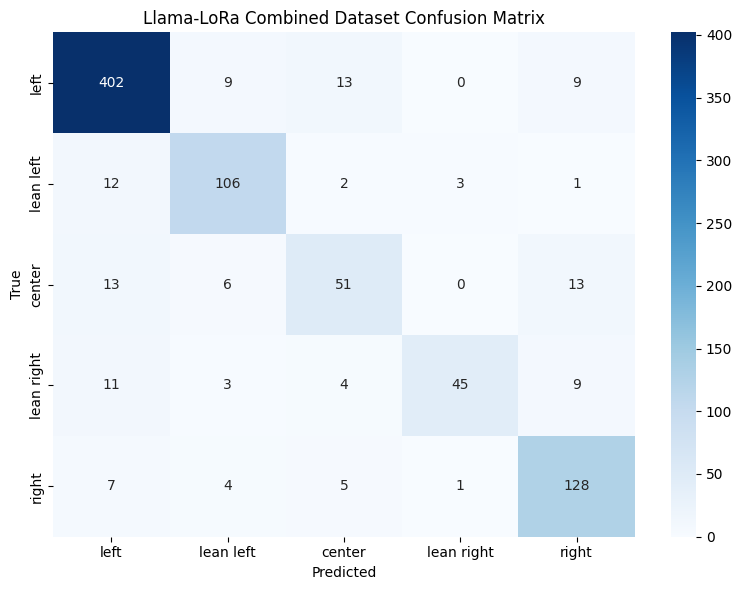

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'Llama-LoRa Combined Dataset');

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for Llama-LoRa Combined Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for Llama-LoRa Combined Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[750  24]
 [ 32  51]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[711  22]
 [ 18 106]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[781   4]
 [ 27  45]]

One-vs-Rest Confusion Matrix for class 'left':
[[381  43]
 [ 31 402]]

One-vs-Rest Confusion Matrix for class 'right':
[[680  32]
 [ 17 128]]


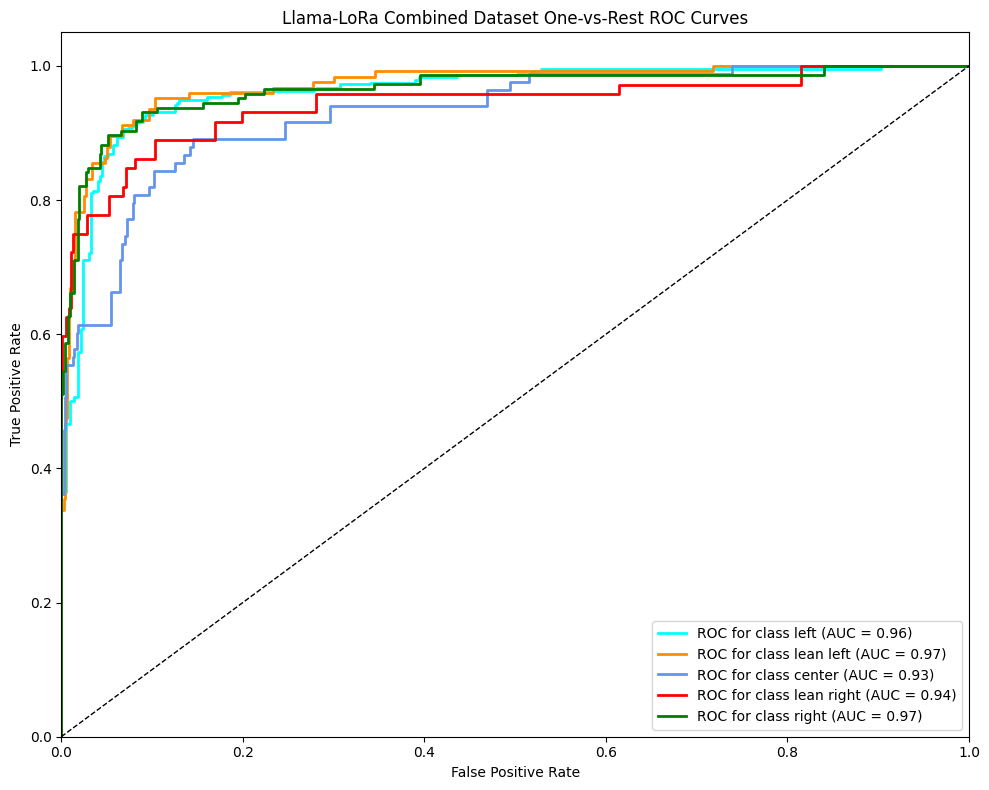

In [12]:
from utils import plot_roc


plot_roc(y_prob, net, test, classes, 'Llama-LoRa Combined Dataset');

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| base data        | 64.76%   | 63.69       |
| combined data    | 85.41    | 85.14       |
